In [2]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import beta, norm
import sys
import os

# Change working directory to scripts
os.chdir(os.path.join(os.getcwd(), 'scripts', 'simulation'))
sys.path.insert(0, os.getcwd())

# Now import directly from the simulation module
from sequence import simulate_sequences  
import rank_correlation as rs
from correlation_mean import add_within_clust_score

nrm = np.load("nrm.npy")


In [3]:
# PARAMETERS
params = {
    "n_neurons": 100,
    "n_motifs": 20,
    "n_bins": 100,
    "n_sequences": 100,
    "sigma_range": (0.02,0.4),    # increasing range makes sequences less similar
    "vol_param": (0.07, 0.9),     # beta distribution:  0.07, 0.9
                                  # a inactive (lower -> more neurons inactive, if high longer seqs, mean len shifts)
                                  # b active (lower -> more neurons active, if <1, skewed to 1, if lower longer seqs, mean len shifts)
    "corr_mu": False,
    "rho_mu": 0.0,
    "corr_sigma": False,
    "rho_sig": 0.0,
    "corr_volume": True,
    "rho_vol": 0.5,
    "shuffle_order": True,       # shuffle order of sequences

}

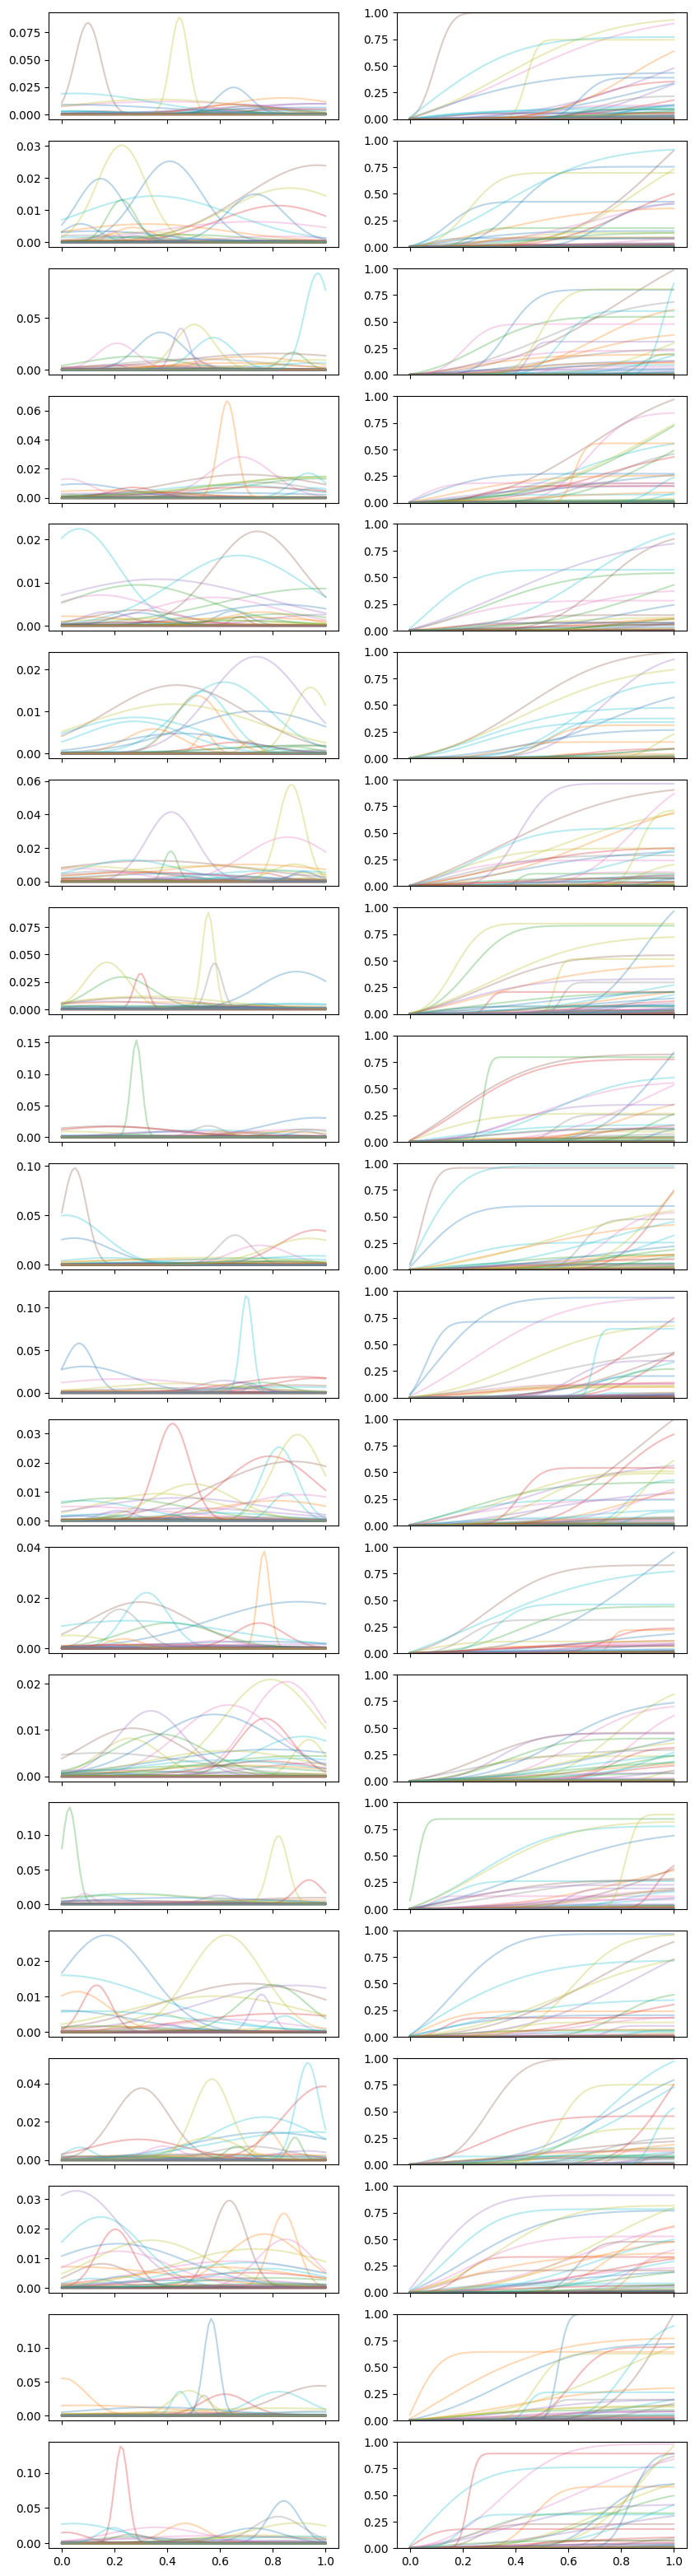

In [4]:

seqs, seqs_labels, spk_times, sequences, true_templates, mu, sigma, volume, densities, cdfs = simulate_sequences(**params, random_state=2, plot=True)

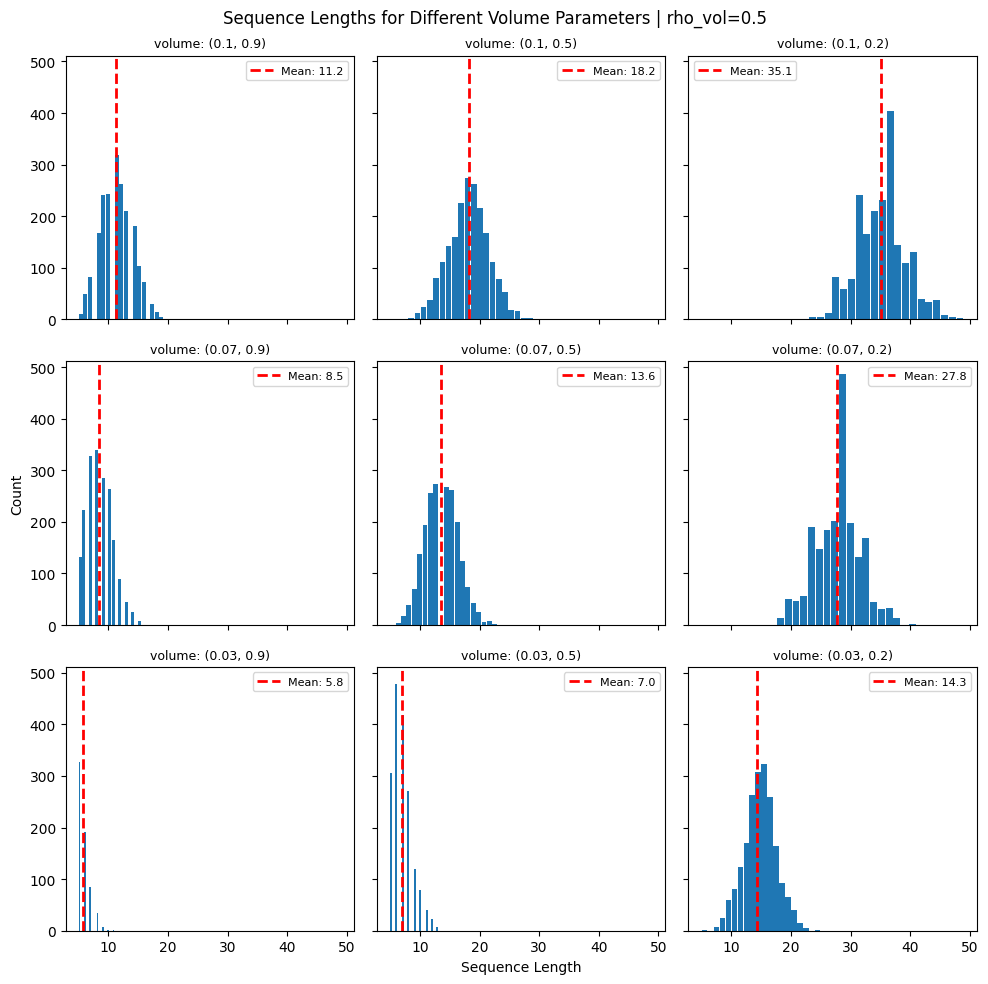

In [5]:
fig, axes = plt.subplots(3, 3, figsize=(10, 10), sharey=True, sharex=True)
fig.suptitle(f"Sequence Lengths for Different Volume Parameters | rho_vol={params['rho_vol']}", fontsize=12)

vol_upper = [0.9, 0.5, 0.2]
vol_lower = [0.1, 0.07, 0.03]

mean_lengths = np.zeros((len(vol_lower), len(vol_upper)))

for row, v_low in enumerate(vol_lower):
    for col, v_high in enumerate(vol_upper):
        lengths = []
        params["vol_param"] = (v_low, v_high)
        seqs_tmp, *_ = simulate_sequences(**params, random_state=2, plot=False)
        lengths = [len(seq) for seq in seqs_tmp]
        mean_lengths[row, col] = np.mean(lengths)

        axes[row, col].hist(lengths, bins=20, rwidth=0.9)
        axes[row, col].axvline(mean_lengths[row, col], color='red', linestyle='dashed', linewidth=2, label=f"Mean: {mean_lengths[row, col]:.1f}")
        axes[row, col].legend(fontsize=8)
        axes[2, 1].set_xlabel('Sequence Length')
        axes[1, 0].set_ylabel('Count')
        axes[row, col].set_title(f'volume: {params["vol_param"]}', fontsize=9)

plt.tight_layout()
plt.show()

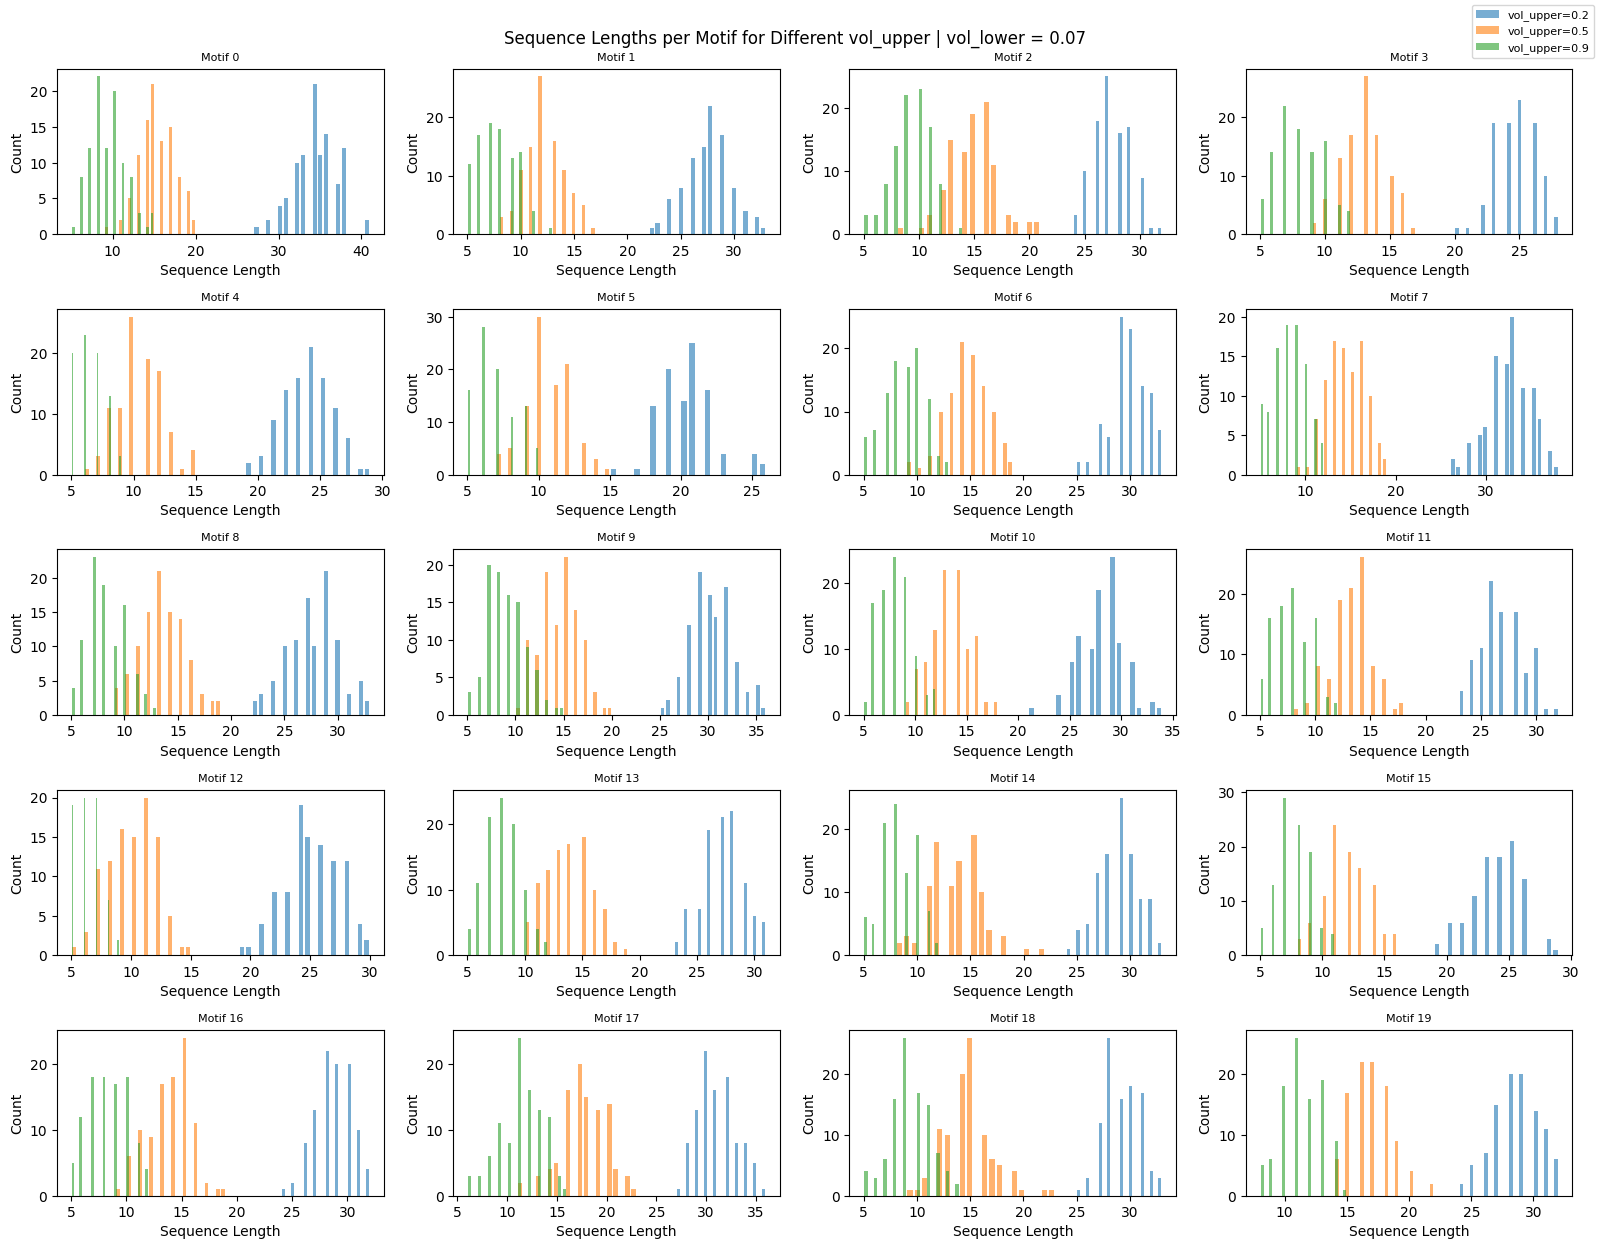

In [6]:
vol_upper = [0.2, 0.5, 0.9]
vol_lower = 0.07  # keep lower fixed

n_motifs = params["n_motifs"]
n_neurons = params["n_neurons"]
n_cols = 4
n_rows = int(np.ceil(n_motifs / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 2.5 * n_rows))
fig.suptitle(f"Sequence Lengths per Motif for Different vol_upper | vol_lower = {vol_lower}", fontsize=12)

colors = ['tab:blue', 'tab:orange', 'tab:green']

# Store legend handles and labels
legend_handles = []
legend_labels = []

for i, v_high in enumerate(vol_upper):
    legend_labels.append(f"vol_upper={v_high}")

for motif in range(n_motifs):
    ax = axes[motif // n_cols, motif % n_cols]
    for i, v_high in enumerate(vol_upper):
        params["vol_param"] = (vol_lower, v_high)
        seqs_tmp, seqs_labels_tmp, *_ = simulate_sequences(**params, random_state=2, plot=False)
        motif_sequences = [seqs_tmp[j] for j, lbl in enumerate(seqs_labels_tmp) if lbl == motif]
        lengths = [len(seq) for seq in motif_sequences]
        n, bins, patches = ax.hist(lengths, bins=20, rwidth=0.7, color=colors[i], alpha=0.6)
        if motif == 0:
            legend_handles.append(patches[0])
    ax.set_title(f"Motif {motif}", fontsize=8)
    ax.set_xlabel("Sequence Length")
    ax.set_ylabel("Count")

# Add one legend for the whole figure
fig.legend(legend_handles, legend_labels, loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

In [5]:
params['vol_param'] = (0.07, 0.9)
params['corr_volume'] = False
params['rho_vol'] = 0.0

seqs_no_corr, seqs_labels_no_corr, spk_times_no_corr, sequences_no_corr, true_templates_no_corr, mu_no_corr, sigma_no_corr, volume_no_corr, densities_no_corr, cdfs_no_corr = simulate_sequences(**params, random_state=2, plot=False)

In [6]:
rep_index, nsig, pval, bmat, zmat, corrmat = rs.allmot(seqs, nrm)
rep_index_no_corr, nsig_no_corr, pval_no_corr, bmat_no_corr, zmat_no_corr, corrmat_no_corr = rs.allmot(seqs_no_corr, nrm)

#### Volume rho = 0.5

/var/folders/xt/5prnt6td6ls550x05vlbl6x40000gn/T/ipykernel_58910/1632562182.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_indices_uncorr)
/var/folders/xt/5prnt6td6ls550x05vlbl6x40000gn/T/ipykernel_58910/1632562182.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_indices_uncorr)


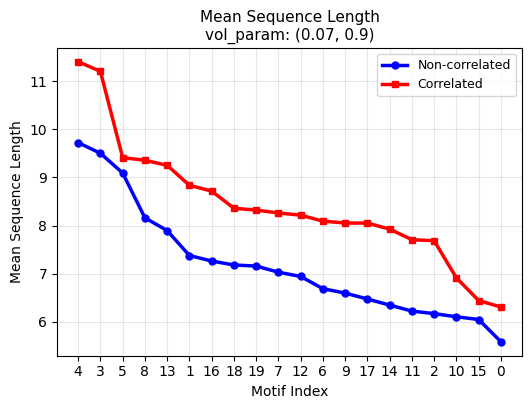

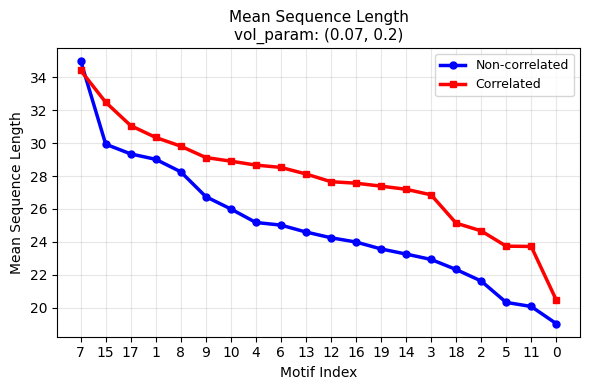

In [10]:
low_vol = (0.07, 0.9)
high_vol = (0.07, 0.2)

vols = [low_vol, high_vol]

# Create plots: one per volume, each with 2 lines (correlated and non-correlated)
for vol_idx, vol in enumerate(vols):
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Generate sequences for this volume WITH correlation
    params['vol_param'] = vol
    params['corr_volume'] = True
    params['rho_vol'] = 0.5
    seqs_corr, seqs_labels_corr, *_ = simulate_sequences(**params, random_state=2, plot=False)
    rep_index_corr, nsig_corr, pval_corr, bmat_corr, zmat_corr, corrmat_corr = rs.allmot(seqs_corr, nrm)
    
    # Generate sequences for this volume WITHOUT correlation
    params['corr_volume'] = False
    params['rho_vol'] = 0.0
    seqs_uncorr, seqs_labels_uncorr, *_ = simulate_sequences(**params, random_state=2, plot=False)
    rep_index_uncorr, nsig_uncorr, pval_uncorr, bmat_uncorr, zmat_uncorr, corrmat_uncorr = rs.allmot(seqs_uncorr, nrm)
    
    # Calculate mean sequence length per motif for non-correlated (this volume)
    mean_lengths_uncorr = []
    for motif in range(params["n_motifs"]):
        motif_seqs = [seqs_uncorr[i] for i, lbl in enumerate(seqs_labels_uncorr) if lbl == motif]
        lengths = [len(seq) for seq in motif_seqs]
        mean_len = np.mean(lengths) if lengths else 0
        mean_lengths_uncorr.append(mean_len)
    mean_lengths_uncorr = np.array(mean_lengths_uncorr)
    
    # Calculate mean sequence length per motif for correlated (this volume)
    mean_lengths_corr = []
    for motif in range(params["n_motifs"]):
        motif_seqs = [seqs_corr[i] for i, lbl in enumerate(seqs_labels_corr) if lbl == motif]
        lengths = [len(seq) for seq in motif_seqs]
        mean_len = np.mean(lengths) if lengths else 0
        mean_lengths_corr.append(mean_len)
    mean_lengths_corr = np.array(mean_lengths_corr)
    
    # Line 1: Non-correlated
    sorted_indices_uncorr = np.argsort(mean_lengths_uncorr)[::-1]  # Sort in descending order
    sorted_mean_uncorr = mean_lengths_uncorr[sorted_indices_uncorr]
    ax.plot(range(len(sorted_mean_uncorr)), sorted_mean_uncorr, 'o-', label='Non-correlated', color='blue', linewidth=2.5, markersize=5)
    
    # Line 2: Correlated
    sorted_indices_corr = np.argsort(mean_lengths_corr)[::-1]  # Sort in descending order
    sorted_mean_corr = mean_lengths_corr[sorted_indices_corr]
    ax.plot(range(len(sorted_mean_corr)), sorted_mean_corr, 's-', label='Correlated', color='red', linewidth=2.5, markersize=5)
    
    ax.set_title(f'Mean Sequence Length\nvol_param: {vol}', fontsize=11)
    ax.set_xlabel('Motif Index')
    ax.set_ylabel('Mean Sequence Length')
    ax.set_xticklabels(sorted_indices_uncorr)   
    ax.set_xticks(range(len(sorted_indices_uncorr)))  
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Volume rho = 0.9

/var/folders/xt/5prnt6td6ls550x05vlbl6x40000gn/T/ipykernel_58910/1351506514.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_indices_uncorr)
/var/folders/xt/5prnt6td6ls550x05vlbl6x40000gn/T/ipykernel_58910/1351506514.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sorted_indices_uncorr)


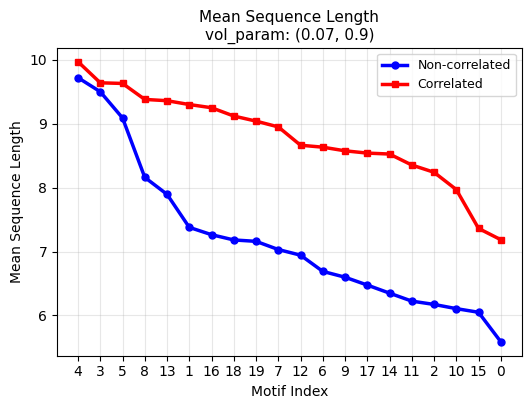

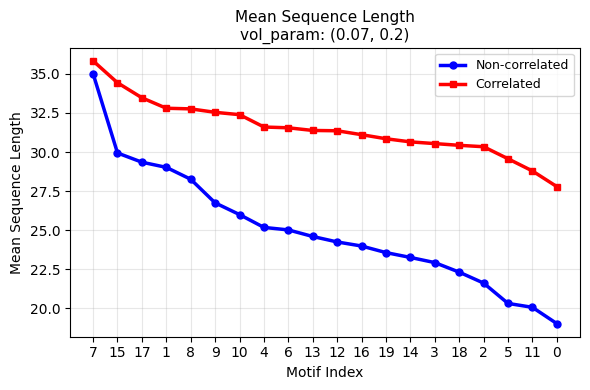

In [11]:
low_vol = (0.07, 0.9)
high_vol = (0.07, 0.2)

vols = [low_vol, high_vol]

# Create plots: one per volume, each with 2 lines (correlated and non-correlated)
for vol_idx, vol in enumerate(vols):
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Generate sequences for this volume WITH correlation
    params['vol_param'] = vol
    params['corr_volume'] = True
    params['rho_vol'] = 0.9
    seqs_corr, seqs_labels_corr, *_ = simulate_sequences(**params, random_state=2, plot=False)
    
    # Generate sequences for this volume WITHOUT correlation
    params['corr_volume'] = False
    params['rho_vol'] = 0.0
    seqs_uncorr, seqs_labels_uncorr, *_ = simulate_sequences(**params, random_state=2, plot=False)

    # Calculate mean sequence length per motif for non-correlated (this volume)
    mean_lengths_uncorr = []
    for motif in range(params["n_motifs"]):
        motif_seqs = [seqs_uncorr[i] for i, lbl in enumerate(seqs_labels_uncorr) if lbl == motif]
        lengths = [len(seq) for seq in motif_seqs]
        mean_len = np.mean(lengths) if lengths else 0
        mean_lengths_uncorr.append(mean_len)
    mean_lengths_uncorr = np.array(mean_lengths_uncorr)
    
    # Calculate mean sequence length per motif for correlated (this volume)
    mean_lengths_corr = []
    for motif in range(params["n_motifs"]):
        motif_seqs = [seqs_corr[i] for i, lbl in enumerate(seqs_labels_corr) if lbl == motif]
        lengths = [len(seq) for seq in motif_seqs]
        mean_len = np.mean(lengths) if lengths else 0
        mean_lengths_corr.append(mean_len)
    mean_lengths_corr = np.array(mean_lengths_corr)
    
    # Line 1: Non-correlated
    sorted_indices_uncorr = np.argsort(mean_lengths_uncorr)[::-1]  # Sort in descending order
    sorted_mean_uncorr = mean_lengths_uncorr[sorted_indices_uncorr]
    ax.plot(range(len(sorted_mean_uncorr)), sorted_mean_uncorr, 'o-', label='Non-correlated', color='blue', linewidth=2.5, markersize=5)
    
    # Line 2: Correlated
    sorted_indices_corr = np.argsort(mean_lengths_corr)[::-1]  # Sort in descending order
    sorted_mean_corr = mean_lengths_corr[sorted_indices_corr]
    ax.plot(range(len(sorted_mean_corr)), sorted_mean_corr, 's-', label='Correlated', color='red', linewidth=2.5, markersize=5)
    
    ax.set_title(f'Mean Sequence Length\nvol_param: {vol}', fontsize=11)
    ax.set_xlabel('Motif Index')
    ax.set_ylabel('Mean Sequence Length')
    ax.set_xticklabels(sorted_indices_uncorr)   
    ax.set_xticks(range(len(sorted_indices_uncorr)))  
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Sigma

#### Sigma rho = 0.5

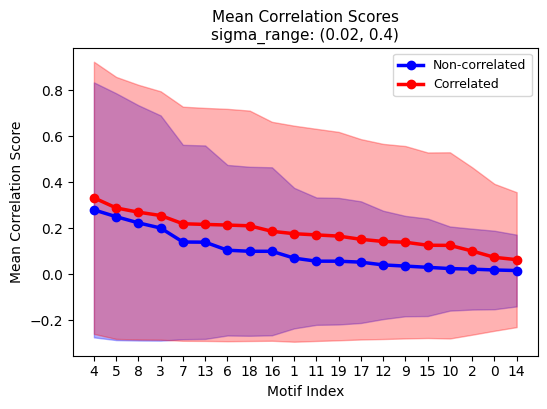

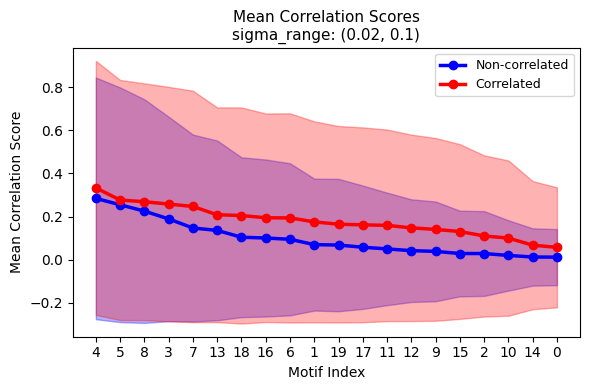

In [ ]:
sigma_low = (0.02, 0.1)
sigma_high = (0.02, 0.4)

sigmas = [sigma_high, sigma_low]

for sigma in sigmas:
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Generate sequences for this volume WITH correlation
    params['sigma_range'] = sigma
    params['vol_param'] = (0.07, 0.9)
    params['corr_volume'] = True
    params['rho_vol'] = 0.5
    seqs_corr, seqs_labels_corr, *_ = simulate_sequences(**params, random_state=2, plot=False)
    rep_index_corr, nsig_corr, pval_corr, bmat_corr, zmat_corr, corrmat_corr = rs.allmot(seqs_corr, nrm)

    # Generate sequences for this volume WITHOUT correlation
    params['corr_volume'] = False
    params['rho_vol'] = 0.0
    seqs_uncorr, seqs_labels_uncorr, *_ = simulate_sequences(**params, random_state=2, plot=False)
    rep_index_uncorr, nsig_uncorr, pval_uncorr, bmat_uncorr, zmat_uncorr, corrmat_uncorr = rs.allmot(seqs_uncorr, nrm)

    # Plot z-scores for correlated and non-correlated and also mean correlation scores with std shading
    mean_corr_scores_corr, varr_corr_scores_corr = add_within_clust_score(seqs_labels_corr, zmat_corr, bmat_corr)
    mean_corr_scores_uncorr, varr_corr_scores_uncorr = add_within_clust_score(seqs_labels_uncorr, zmat_uncorr, bmat_uncorr)

    sorted_indices_uncorr = np.argsort(mean_corr_scores_uncorr)[::-1]  # Sort in descending order
    sorted_mean_corr_scores_uncorr = mean_corr_scores_uncorr[sorted_indices_uncorr]
    sorted_varr_corr_scores_uncorr = varr_corr_scores_uncorr[sorted_indices_uncorr]
    sorted_indices_corr = np.argsort(mean_corr_scores_corr)[::-1]  # Sort in descending order
    sorted_mean_corr_scores_corr = mean_corr_scores_corr[sorted_indices_corr]
    sorted_varr_corr_scores_corr = varr_corr_scores_corr[sorted_indices_corr]
    
    ax.plot(range(len(sorted_mean_corr_scores_uncorr)), sorted_mean_corr_scores_uncorr, 'o-', label='Non-correlated', color='blue', linewidth=2.5)
    ax.fill_between(range(len(sorted_mean_corr_scores_uncorr)), sorted_mean_corr_scores_uncorr - np.sqrt(sorted_varr_corr_scores_uncorr), sorted_mean_corr_scores_uncorr + np.sqrt(sorted_varr_corr_scores_uncorr), color='blue', alpha=0.3)
    ax.plot(range(len(sorted_mean_corr_scores_corr)), sorted_mean_corr_scores_corr, 'o-', label='Correlated', color='red', linewidth=2.5)
    ax.fill_between(range(len(sorted_mean_corr_scores_corr)), sorted_mean_corr_scores_corr - np.sqrt(sorted_varr_corr_scores_corr), sorted_mean_corr_scores_corr + np.sqrt(sorted_varr_corr_scores_corr), color='red', alpha=0.3)
    ax.set_title(f'Mean Correlation Scores\nsigma_range: {sigma}', fontsize=11)
    ax.set_xlabel('Motif Index')
    ax.set_ylabel('Mean Correlation Score')
    ax.set_xticks(range(len(sorted_indices_uncorr)))
    ax.set_xticklabels(sorted_indices_uncorr)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

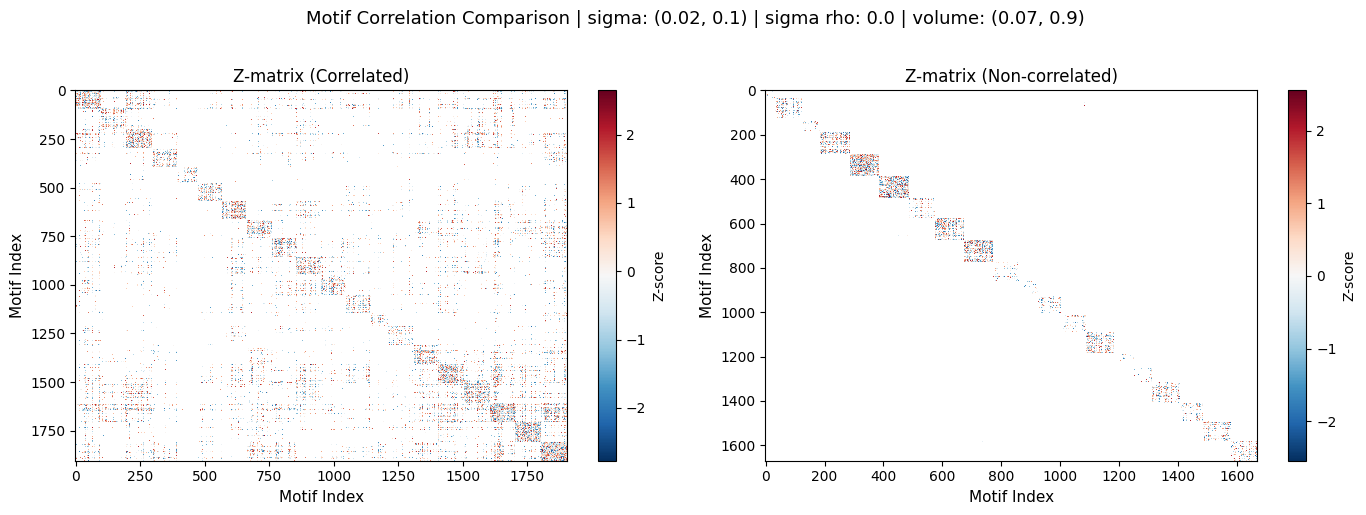

In [ ]:
# from above - Compare Z-matrices for correlated and non-correlated
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlated
im1 = axes[0].imshow(zmat_corr, aspect='auto', cmap='RdBu_r', interpolation='nearest')
axes[0].set_ylabel('Motif Index', fontsize=11)
axes[0].set_xlabel('Motif Index', fontsize=11)
axes[0].set_title('Z-matrix (Correlated)', fontsize=12)
cbar1 = plt.colorbar(im1, ax=axes[0], label='Z-score')

# Non-correlated
im2 = axes[1].imshow(zmat_uncorr, aspect='auto', cmap='RdBu_r', interpolation='nearest')
axes[1].set_ylabel('Motif Index', fontsize=11)
axes[1].set_xlabel('Motif Index', fontsize=11)
axes[1].set_title('Z-matrix (Non-correlated)', fontsize=12)
cbar2 = plt.colorbar(im2, ax=axes[1], label='Z-score')

plt.suptitle(f'Motif Correlation Comparison | sigma: {sigma} | sigma rho: 0.5 | volume: {params["vol_param"]}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

#### Sigma rho = 0.9

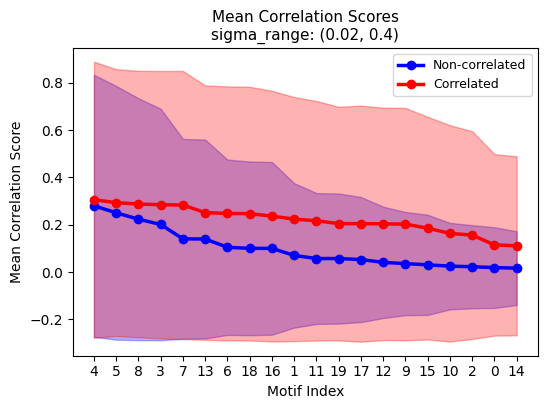

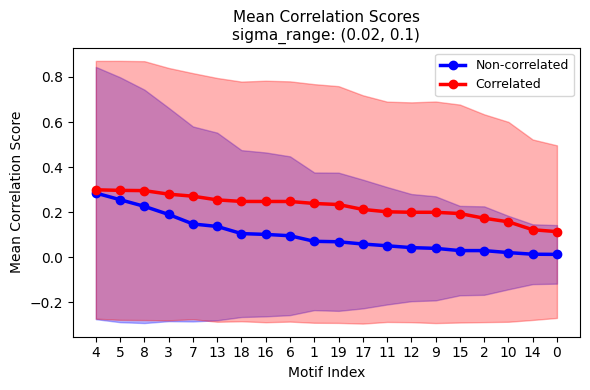

In [31]:
sigma_low = (0.02, 0.1)
sigma_high = (0.02, 0.4)

sigmas = [sigma_high, sigma_low]

for sigma in sigmas:
    fig, ax = plt.subplots(figsize=(6, 4))
    
    # Generate sequences for this volume WITH correlation
    params['sigma_range'] = sigma
    params['vol_param'] = (0.07, 0.9)
    params['corr_volume'] = True
    params['rho_vol'] = 0.9
    seqs_corr, seqs_labels_corr, *_ = simulate_sequences(**params, random_state=2, plot=False)
    rep_index_corr, nsig_corr, pval_corr, bmat_corr, zmat_corr, corrmat_corr = rs.allmot(seqs_corr, nrm)

    # Generate sequences for this volume WITHOUT correlation
    params['corr_volume'] = False
    params['rho_vol'] = 0.0
    seqs_uncorr, seqs_labels_uncorr, *_ = simulate_sequences(**params, random_state=2, plot=False)
    rep_index_uncorr, nsig_uncorr, pval_uncorr, bmat_uncorr, zmat_uncorr, corrmat_uncorr = rs.allmot(seqs_uncorr, nrm)

    # Plot z-scores for correlated and non-correlated and also mean correlation scores with std shading
    mean_corr_scores_corr, varr_corr_scores_corr = add_within_clust_score(seqs_labels_corr, zmat_corr, bmat_corr)
    mean_corr_scores_uncorr, varr_corr_scores_uncorr = add_within_clust_score(seqs_labels_uncorr, zmat_uncorr, bmat_uncorr)

    sorted_indices_uncorr = np.argsort(mean_corr_scores_uncorr)[::-1]  # Sort in descending order
    sorted_mean_corr_scores_uncorr = mean_corr_scores_uncorr[sorted_indices_uncorr]
    sorted_varr_corr_scores_uncorr = varr_corr_scores_uncorr[sorted_indices_uncorr]
    sorted_indices_corr = np.argsort(mean_corr_scores_corr)[::-1]  # Sort in descending order
    sorted_mean_corr_scores_corr = mean_corr_scores_corr[sorted_indices_corr]
    sorted_varr_corr_scores_corr = varr_corr_scores_corr[sorted_indices_corr]
    
    ax.plot(range(len(sorted_mean_corr_scores_uncorr)), sorted_mean_corr_scores_uncorr, 'o-', label='Non-correlated', color='blue', linewidth=2.5)
    ax.fill_between(range(len(sorted_mean_corr_scores_uncorr)), sorted_mean_corr_scores_uncorr - np.sqrt(sorted_varr_corr_scores_uncorr), sorted_mean_corr_scores_uncorr + np.sqrt(sorted_varr_corr_scores_uncorr), color='blue', alpha=0.3)
    ax.plot(range(len(sorted_mean_corr_scores_corr)), sorted_mean_corr_scores_corr, 'o-', label='Correlated', color='red', linewidth=2.5)
    ax.fill_between(range(len(sorted_mean_corr_scores_corr)), sorted_mean_corr_scores_corr - np.sqrt(sorted_varr_corr_scores_corr), sorted_mean_corr_scores_corr + np.sqrt(sorted_varr_corr_scores_corr), color='red', alpha=0.3)
    ax.set_title(f'Mean Correlation Scores\nsigma_range: {sigma}', fontsize=11)
    ax.set_xlabel('Motif Index')
    ax.set_ylabel('Mean Correlation Score')
    ax.set_xticks(range(len(sorted_indices_uncorr)))
    ax.set_xticklabels(sorted_indices_uncorr)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

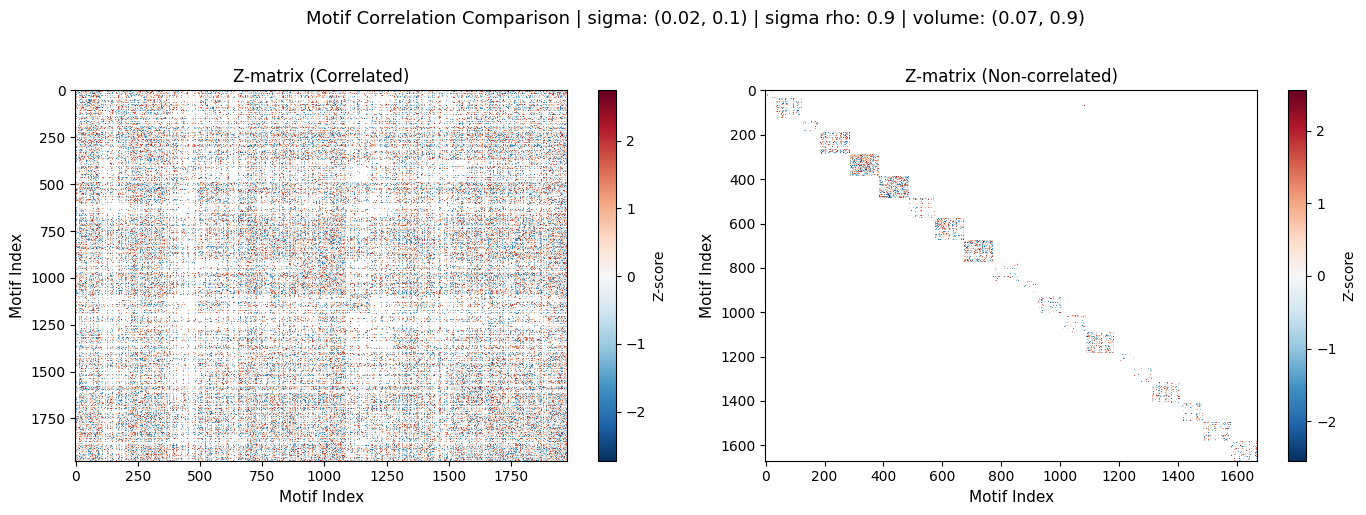

In [33]:
# from above - Compare Z-matrices for correlated and non-correlated
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlated
im1 = axes[0].imshow(zmat_corr, aspect='auto', cmap='RdBu_r', interpolation='nearest')
axes[0].set_ylabel('Motif Index', fontsize=11)
axes[0].set_xlabel('Motif Index', fontsize=11)
axes[0].set_title('Z-matrix (Correlated)', fontsize=12)
cbar1 = plt.colorbar(im1, ax=axes[0], label='Z-score')

# Non-correlated
im2 = axes[1].imshow(zmat_uncorr, aspect='auto', cmap='RdBu_r', interpolation='nearest')
axes[1].set_ylabel('Motif Index', fontsize=11)
axes[1].set_xlabel('Motif Index', fontsize=11)
axes[1].set_title('Z-matrix (Non-correlated)', fontsize=12)
cbar2 = plt.colorbar(im2, ax=axes[1], label='Z-score')

plt.suptitle(f'Motif Correlation Comparison | sigma: {sigma} | sigma rho: 0.9 | volume: {params["vol_param"]}', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()